In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr
from lifelines import KaplanMeierFitter
from scipy.stats import pointbiserialr
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")
from DadosAbertosBrasil import ibge
import folium
from branca.colormap import linear
import geopandas as gpd


/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
df_oncologia = pd.read_csv("./dados/dados_oncologicos_filtrados.csv")
df_oncologia = df_oncologia[[ 'ANO_DIAGN', 'ANO_TRATAM','UF_RESID', 'MUN_RESID', 'UF_TRATAM', 'MUN_TRATAM', 'TRATAMENTO', 'IDADE','ESTADIAM','TEMPO_TRAT','DIAG_DETH', 'DT_DIAG', 'DT_TRAT', 'DT_NASC']]
df_oncologia = df_oncologia.rename(columns={
    "ANO_DIAGN": "ano_diagnostico", 
    "ANO_TRATAM": "ano_tratamento", 
    "UF_RESID": "uf_residencia", 
    "MUN_RESID": "codigo_municipio_residencia", 
    "UF_TRATAM": "uf_tratamento", 
    "MUN_TRATAM": "codigo_municipio_tratamento", 
    "ESTADIAM": "estadiamento", 
    "TEMPO_TRAT": "tempo_tratamento",
    "DIAG_DETH": "diagnostico",
    "DT_DIAG": "data_diagnostico",
    "DT_TRAT": "data_tratamento",
    "DT_NASC": "data_nascimento",
})

df_sim = pd.read_csv("./dados/dados_processados_SIM_filtrado.csv")
df_sim = df_sim[['DTOBITO', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'ESC', 'CODMUNRES', 'CAUSABAS']]
df_sim = df_sim.rename(columns={
    "DTOBITO": "data_obito", 
    "DTNASC": "data_nascimento", 
    "IDADE": "idade", 
    "SEXO": "sexo", 
    "RACACOR": "raca_cor", 
    "ESC2010": "escolaridade_2010", 
    "ESC": "escolaridade", 
    "CODMUNRES": "codigo_municipio_residencia",
    "CAUSABAS": "causa_obito"
})


df_regiao = pd.read_csv("./dados/ibge/municipios_regioes.csv")
df_regiao = df_regiao[['codigo_municipio_ibge_novo', 'nome_municipio', 'nome_uf', 'uf', 'regiao', "cod_uf"]]
df_regiao = df_regiao.rename(columns={
    "codigo_municipio_ibge_novo": "codigo_municipio_residencia"
})
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].astype(str)
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].str.slice(0, 6)

df_sim['data_obito'] = pd.to_datetime(df_sim['data_obito'])
df_sim['ano_obito'] = df_sim['data_obito'].dt.year
df_oncologia = df_oncologia[df_oncologia['ano_tratamento'] < 2020]

for col in ["data_diagnostico", "data_tratamento", "data_nascimento"]:
    df_oncologia[col] = pd.to_datetime(df_oncologia[col], errors="coerce", format="%Y-%m-%d")

for col in ["data_nascimento", "data_obito"]:
    df_sim[col] = pd.to_datetime(df_sim[col], errors="coerce", format="%Y-%m-%d")


df_sim['causa_obito'] = df_sim['causa_obito'].str[:3] 
df_oncologia['diagnostico'] = df_oncologia['diagnostico'].str[:3]

print("Casos oncologia: ", len(df_oncologia))
print("Casos mortalidade: ", len(df_sim))

df_merge = df_oncologia.merge(
    df_sim,
    left_on=['codigo_municipio_residencia', 'data_nascimento', 'diagnostico'],
    right_on=['codigo_municipio_residencia', 'data_nascimento', 'causa_obito'],
    how='inner'
)
df_merge['codigo_municipio_residencia'] = df_merge['codigo_municipio_residencia'].astype(str)
df_merge['codigo_municipio_residencia'] = df_merge['codigo_municipio_residencia'].str.slice(0, 6)
df_merge['obito'] = df_merge['data_obito'].notnull()
dados_completos = pd.merge(df_merge, df_regiao, on='codigo_municipio_residencia', how='inner')

df_merge_completo = dados_completos.copy()

def validar_casos(row):
    if pd.isna(row['data_obito']):
        return "Válido (Sem óbito)"
    elif row['data_obito'] < row['data_diagnostico'] and row['data_obito'] < row['data_tratamento']:
        return "Óbito antes de diagnóstico e tratamento"
    elif row['data_obito'] < row['data_diagnostico']:
        return "Óbito antes do diagnóstico"
    elif row['data_obito'] < row['data_tratamento']:
        return "Óbito antes do diagnóstico"
    else:
        return "Válido"

df_merge_completo['status_validacao'] = df_merge_completo.apply(validar_casos, axis=1)
print(df_merge_completo['status_validacao'].value_counts())
df_merge_completo = df_merge_completo.query("status_validacao == 'Válido (Sem óbito)' or status_validacao == 'Válido'")
df_merge_completo = df_merge_completo.drop_duplicates(subset=["codigo_municipio_residencia", "data_nascimento", "diagnostico"], keep="first")
df_merge_completo['tempo_diagnostico_primeiro_tratamento'] = (df_merge_completo['data_tratamento'] - df_merge_completo['data_diagnostico']).dt.days


Casos oncologia:  12477
Casos mortalidade:  73737
status_validacao
Válido                                     1853
Óbito antes de diagnóstico e tratamento      88
Óbito antes do diagnóstico                   16
Name: count, dtype: int64


### Tempo inicio tratmento casos que levaram ao óbito com tratamentos de 2017

In [5]:
dados_completos_cp = df_merge_completo.copy()
dados_completos_cp = dados_completos_cp.query("tempo_tratamento != 99999")
dados_completos_cp = dados_completos_cp[dados_completos_cp['tempo_tratamento'].notna()]
dados_completos_cp = dados_completos_cp[dados_completos_cp['ano_tratamento'] == 2017]

In [6]:
casos_acima_60 = dados_completos_cp[dados_completos_cp["tempo_tratamento"] > 60].groupby("cod_uf").size()
total_casos = dados_completos_cp.groupby("cod_uf").size()
percentual = (casos_acima_60 / total_casos).fillna(0) * 100
percentual = percentual.reset_index(name="percentual_acima_60_dias").round({"percentual_acima_60_dias": 4})
percentual.to_clipboard(decimal=",")

In [ ]:
geojson_path = ibge.malha(
    nivel = 'paises',
    localidade = 'BR',
    divisoes = 'uf',
    formato = 'geojson'
)
mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles=None)
#colormap = linear.YlOrRd_09.scale(percentual["percentual_acima_60_dias"].min(), percentual["percentual_acima_60_dias"].max())
colormap = linear.YlOrRd_09.scale(0, 100) 
colormap.caption = 'Percentual de casos com tratamento após 60 dias (%)'
colormap.caption = 'Tempo médio de tratamento (dias)'
folium.Choropleth(
    geo_data=geojson_path,
    data=percentual,
    columns=["cod_uf", "percentual_acima_60_dias"],
    key_on="feature.properties.codarea",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Tempo médio de tratamento (dias)",
    nan_fill_color="white",
    nan_fill_opacity=0.3
).add_to(mapa)

if isinstance(geojson_path, dict):
    gdf = gpd.GeoDataFrame.from_features(geojson_path["features"])
else:
    gdf = gpd.read_file(geojson_path)  

gdf["codarea"] = gdf["codarea"].astype(int)

for _, row in gdf.iterrows():
    estado_codigo = row["codarea"]
    centroide = row.geometry.centroid  
    tempo_tratamento = percentual.loc[percentual["cod_uf"] == estado_codigo, "percentual_acima_60_dias"]
    if not tempo_tratamento.empty:
        valor = f"{round(tempo_tratamento.values[0], 1)}%" 
        folium.Marker(
            location=[centroide.y, centroide.x], 
            icon=folium.DivIcon(html=f"""
                <div style="
                    font-size: 12px; 
                    font-weight: bold; 
                    color: black; 
                    background: rgba(255,255,255,0.85);
                    padding: 4px 6px;
                    border-radius: 5px;
                    text-align: center;
                    display: inline-block;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
                    border: 1px solid rgba(0,0,0,0.2);
                ">
                    {valor}
                </div>""")
        ).add_to(mapa)
mapa.get_root().html.add_child(folium.Element("""
    <style>
        html, body {
            background-color: white !important;
            height: 100%;
            margin: 0;
        }
        .folium-map { background: white; }
        #map { height: 100%; }
    </style>
"""))
mapa.save("teste.html")


In [8]:
df_oncologia = pd.read_csv("./dados/dados_oncologicos_filtrados.csv")
df_oncologia = df_oncologia[[ 'ANO_DIAGN', 'ANO_TRATAM','UF_RESID', 'MUN_RESID', 'UF_TRATAM', 'MUN_TRATAM', 'TRATAMENTO', 'IDADE','ESTADIAM','TEMPO_TRAT','DIAG_DETH', 'DT_DIAG', 'DT_TRAT', 'DT_NASC']]
df_oncologia = df_oncologia.rename(columns={
    "ANO_DIAGN": "ano_diagnostico", 
    "ANO_TRATAM": "ano_tratamento", 
    "UF_RESID": "uf_residencia", 
    "MUN_RESID": "codigo_municipio_residencia", 
    "UF_TRATAM": "uf_tratamento", 
    "MUN_TRATAM": "codigo_municipio_tratamento", 
    "ESTADIAM": "estadiamento", 
    "TEMPO_TRAT": "tempo_tratamento",
    "DIAG_DETH": "diagnostico",
    "DT_DIAG": "data_diagnostico",
    "DT_TRAT": "data_tratamento",
    "DT_NASC": "data_nascimento",
})

df_sim = pd.read_csv("./dados/dados_processados_SIM_filtrado.csv")
df_sim = df_sim[['DTOBITO', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'ESC', 'CODMUNRES', 'CAUSABAS']]
df_sim = df_sim.rename(columns={
    "DTOBITO": "data_obito", 
    "DTNASC": "data_nascimento", 
    "IDADE": "idade", 
    "SEXO": "sexo", 
    "RACACOR": "raca_cor", 
    "ESC2010": "escolaridade_2010", 
    "ESC": "escolaridade", 
    "CODMUNRES": "codigo_municipio_residencia",
    "CAUSABAS": "causa_obito"
})


df_regiao = pd.read_csv("./dados/ibge/municipios_regioes.csv")
df_regiao = df_regiao[['codigo_municipio_ibge_novo', 'nome_municipio', 'nome_uf', 'uf', 'regiao', "cod_uf"]]
df_regiao = df_regiao.rename(columns={
    "codigo_municipio_ibge_novo": "codigo_municipio_residencia"
})
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].astype(str)
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].str.slice(0, 6)

df_sim['data_obito'] = pd.to_datetime(df_sim['data_obito'])
df_sim['ano_obito'] = df_sim['data_obito'].dt.year
df_oncologia = df_oncologia[df_oncologia['ano_tratamento'] < 2020]

for col in ["data_diagnostico", "data_tratamento", "data_nascimento"]:
    df_oncologia[col] = pd.to_datetime(df_oncologia[col], errors="coerce", format="%Y-%m-%d")

for col in ["data_nascimento", "data_obito"]:
    df_sim[col] = pd.to_datetime(df_sim[col], errors="coerce", format="%Y-%m-%d")


df_sim['causa_obito'] = df_sim['causa_obito'].str[:3] 
df_oncologia['diagnostico'] = df_oncologia['diagnostico'].str[:3]

print("Casos oncologia: ", len(df_oncologia))
print("Casos mortalidade: ", len(df_sim))

df_merge = df_oncologia.merge(
    df_sim,
    left_on=['codigo_municipio_residencia', 'data_nascimento', 'diagnostico'],
    right_on=['codigo_municipio_residencia', 'data_nascimento', 'causa_obito'],
    how='inner'
)
df_merge['codigo_municipio_residencia'] = df_merge['codigo_municipio_residencia'].astype(str)
df_merge['codigo_municipio_residencia'] = df_merge['codigo_municipio_residencia'].str.slice(0, 6)
df_merge['obito'] = df_merge['data_obito'].notnull()
dados_completos = pd.merge(df_merge, df_regiao, on='codigo_municipio_residencia', how='inner')

df_merge_completo = dados_completos.copy()

def validar_casos(row):
    if pd.isna(row['data_obito']):
        return "Válido (Sem óbito)"
    elif row['data_obito'] < row['data_diagnostico'] and row['data_obito'] < row['data_tratamento']:
        return "Óbito antes de diagnóstico e tratamento"
    elif row['data_obito'] < row['data_diagnostico']:
        return "Óbito antes do diagnóstico"
    elif row['data_obito'] < row['data_tratamento']:
        return "Óbito antes do tratamento"
    else:
        return "Válido"

df_merge_completo['status_validacao'] = df_merge_completo.apply(validar_casos, axis=1)
print(df_merge_completo['status_validacao'].value_counts())
df_merge_completo = df_merge_completo.query("status_validacao == 'Válido (Sem óbito)' or status_validacao == 'Válido'")
df_merge_completo = df_merge_completo.drop_duplicates(subset=["codigo_municipio_residencia", "data_nascimento", "diagnostico"], keep="first")

Casos oncologia:  12477
Casos mortalidade:  73737
status_validacao
Válido                                     1853
Óbito antes de diagnóstico e tratamento      88
Óbito antes do tratamento                    15
Óbito antes do diagnóstico                    1
Name: count, dtype: int64


In [9]:
from lifelines import CoxPHFitter

df_merge_completo["data_diagnostico"] = pd.to_datetime(df_merge_completo["data_diagnostico"])
df_merge_completo["data_tratamento"] = pd.to_datetime(df_merge_completo["data_tratamento"])

df_merge_completo = df_merge_completo.query("estadiamento != 5")

df_merge_completo["tempo_diagnostico_tratamento"] = (df_merge_completo["data_tratamento"] - df_merge_completo["data_diagnostico"]).dt.days

df_merge_completo["tempo_tratamento_obito"] = (pd.to_datetime(df_merge_completo["data_obito"]) - df_merge_completo["data_tratamento"]).dt.days
df_merge_completo["tempo_tratamento_obito"] = df_merge_completo["tempo_tratamento_obito"].where(df_merge_completo["data_obito"].notna())  
df_merge_completo["obito"] = df_merge_completo["data_obito"].notna().astype(int)

df_merge_completo["tempo_tratamento_obito"].fillna(0, inplace=True)

In [120]:
len(df_merge_completo)

1822

In [114]:
cph = CoxPHFitter()
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(df_merge_completo, duration_col="tempo_tratamento_obito", event_col="obito", formula="tempo_diagnostico_tratamento + estadiamento")
teste = cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1102 total observations, 0 right-censored observations>
             duration col = 'tempo_tratamento_obito'
                event col = 'obito'
      baseline estimation = breslow
   number of observations = 1102
number of events observed = 1102
   partial log-likelihood = -6619.19
         time fit was run = 2025-02-26 23:24:13 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
tempo_diagnostico_tratamento -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
estadiamento                  0.07      1.07      0.03            0.01            0.12                1.01                1.13

                              cmp to     z    p  -log2(p)
covariate                                                
tempo_diagnostico_tratamento    0.00 -0.15 0.88      0.19
estadiamento                    0.00  2.23 0.03      5.28
---
Concordance = 0.52
Partial AIC = 13242.39
log-likelihood ratio test = 5.22 on 2 df
-log2(p) of ll-ratio test = 3.76

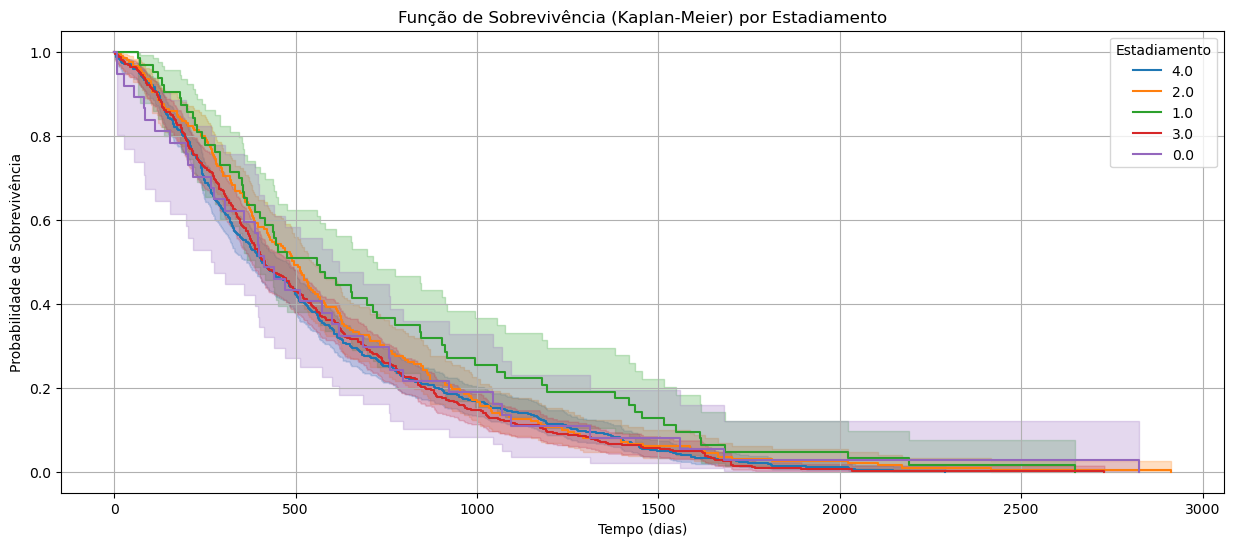

In [10]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
plt.figure(figsize=(15, 6))

for estadiamento_value in df_merge_completo['estadiamento'].unique():
    subset = df_merge_completo[df_merge_completo['estadiamento'] == estadiamento_value]
    
    kmf.fit(durations=subset['tempo_tratamento_obito'], event_observed=subset['obito'], label=str(estadiamento_value))
    kmf.plot_survival_function()

plt.title('Função de Sobrevivência (Kaplan-Meier) por Estadiamento')
plt.xlabel('Tempo (dias)')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend(title="Estadiamento")
plt.grid(True)
plt.show()
